## Dataset and Lib Initiate

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





UsageError: Line magic function `%autoreload` not found.


In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

# rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the test and test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Inhalation toxicity\dataset\test_set_acute_inhalation_features.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

# modred string handler
if 'Modred_Descriptor' in test_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list_float)

print("------test DataFrame UnCalculate------")
print(test_df.head(2))

# Rdkit Calculate
calc_rows = []

for smiles in test_df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        # Molecular Weight 
        mw = Descriptors.MolWt(mol)
        
        # XLogP (LogP)
        logp = Descriptors.MolLogP(mol)
        # H-Bond Donors & Acceptors
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        # Rotatable Bonds
        rotb = Descriptors.NumRotatableBonds(mol)       
        # TopoPSA
        tpsa = Descriptors.TPSA(mol)       
        # Fsp3
        fsp3 = Lipinski.FractionCSP3(mol)       
        # Petitjean Number (Graph Descriptor)
        try: petitjean = rdMolDescriptors.CalcPetitjeanNumber(mol)
        except: petitjean = 0.5          
        # InChI Code 
        try: inchi = Chem.MolToInchi(mol)
        except: inchi = "-"    
        # Lipinski Failures 
        failures = 0
        if mw > 500: failures += 1
        if logp > 5: failures += 1
        if hbd > 5: failures += 1
        if hba > 10: failures += 1
        
        # VAdjMat (Approximation using BalabanJ as Graph Complexity)
        vadjmat = Descriptors.BalabanJ(mol)
        
        # input ke dictionary
        row_calc = {
            'Molecular weight': mw,
            'Molecule (RDKit Mol) (InChI Code)': inchi,
            'nHBDon': float(hbd),
            'nAtomLAC': float(hba), # Seringkali nAtomLAC di map ke H-Acceptor atau fitur atom lain
            'nAtomLC': float(mol.GetNumHeavyAtoms()), # Linear Count / Heavy Atoms approximation
            'PetitjeanNumber': petitjean,
            'nRotB': float(rotb),
            'LipinskiFailures': float(failures),
            'TopoPSA': tpsa,
            'VAdjMat': vadjmat,
            'XLogP': logp,
            'Fsp3': fsp3
        }
    else:
        row_calc = {k: None for k in ['Molecular weight', 'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3']}

    calc_rows.append(row_calc)

df_calc = pd.DataFrame(calc_rows)

for col in df_calc.columns:
    test_df[col] = df_calc[col]

target_cols_order = [
    'id', 'casrn', 'smiles (First)', 'Molecular weight', 
    'name', 'Outcome', 
    'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form',
    'ID', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 
    'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

valid_cols = [c for c in target_cols_order if c in test_df.columns]
final_test_df = test_df[valid_cols]

print("-----Test DataFrame------")
pd.set_option('display.max_columns', None) 
print(final_test_df.head())

------test DataFrame UnCalculate------
     id     casrn smiles (First)   Molecular weight                name  \
0  2564   64-19-7                 60.05195999145508         acetic acid   
1  1454  110-76-9                 90.14418029785156  2-ethoxyethanamine   

  Outcome         Molecule (RDKit Mol) (InChI Code) reference molecule_form  \
0       1     InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)      ECHA             V   
1       0  InChI=1S/C4H11NO/c1-2-6-4-3-5/h2-5H2,1H3      ECHA             V   

  ID RowID                                 Morgan_Descriptors  \
0      282  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1      183  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   SMILES  
0  [-0.9933128039738658, -1.3775249672735086, -1....  CC(=O)O  
1  [

## Physiochemical (ChemProp) Calculate

In [3]:
from rdkit.Chem import Descriptors, GraphDescriptors, MolSurf, Lipinski, rdMolDescriptors, Crippen

# KALKULASI DESKRIPTOR LENGKAP (MATCHING EXPECTED OUTPUT)

full_data = []

for smiles in test_df['SMILES']:
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
    else:
        mol = None
    
    if mol:
        # --- A. BASIC PROPERTIES ---
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol) # Ini Crippen LogP (biasa dipakai untuk ALogP/XLogP)
        mr = Descriptors.MolMR(mol)     # Molar Refractivity (AMR)
        tpsa = Descriptors.TPSA(mol)
        labute = Descriptors.LabuteASA(mol)
        
        # --- B. COUNTS (ATOM/BOND/RING) ---
        num_atoms = mol.GetNumAtoms()
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        num_rotb = Descriptors.NumRotatableBonds(mol)
        num_hbd = Descriptors.NumHDonors(mol)
        num_hba = Descriptors.NumHAcceptors(mol)
        num_hetero = Descriptors.NumHeteroatoms(mol)
        num_amide = rdMolDescriptors.CalcNumAmideBonds(mol)
        
        # Ring Specifics
        n_aro_rings = Descriptors.NumAromaticRings(mol)
        n_sat_rings = Descriptors.NumSaturatedRings(mol)
        n_ali_rings = Descriptors.NumAliphaticRings(mol)
        n_aro_het = Descriptors.NumAromaticHeterocycles(mol)
        n_sat_het = Descriptors.NumSaturatedHeterocycles(mol)
        n_ali_het = Descriptors.NumAliphaticHeterocycles(mol)
        n_aro_carb = Descriptors.NumAromaticCarbocycles(mol)
        n_sat_carb = Descriptors.NumSaturatedCarbocycles(mol)
        n_ali_carb = Descriptors.NumAliphaticCarbocycles(mol)

        # --- C. CONNECTIVITY & SHAPE (CHI / KAPPA / HALLKIER) ---
        # Chi Path
        chi0v = GraphDescriptors.Chi0v(mol)
        chi1v = GraphDescriptors.Chi1v(mol)
        chi2v = GraphDescriptors.Chi2v(mol)
        chi3v = GraphDescriptors.Chi3v(mol)
        chi4v = GraphDescriptors.Chi4v(mol)
        
        chi1n = GraphDescriptors.Chi1n(mol)
        chi2n = GraphDescriptors.Chi2n(mol)
        chi3n = GraphDescriptors.Chi3n(mol)
        chi4n = GraphDescriptors.Chi4n(mol)
        
        # Kappa & HallKier
        hallkier = GraphDescriptors.HallKierAlpha(mol)
        kappa1 = GraphDescriptors.Kappa1(mol)
        kappa2 = GraphDescriptors.Kappa2(mol)
        kappa3 = GraphDescriptors.Kappa3(mol)
        
        # --- D. OTHER SPECIFICS ---
        fsp3 = Lipinski.FractionCSP3(mol)
        
        # Approximation for CDK-specific names using RDKit equivalents
        # Beberapa nama kolom di bawah adalah khas CDK, kita pakai nilai RDKit yang relevan/sama
        bpol = Descriptors.HeavyAtomMolWt(mol) # Placeholder/Approx (bpol CDK beda rumus, tapi sering dipakai sbg heavy wt di bbrp script)
        eccen = 0.0 # Eccentric Connectivity Index tidak ada di RDKit standar
        fragc = 0.0 # Fragment Count tidak spesifik
        
        # Mapping ke Nama Kolom Target
        row = {
            # Duplicates/Aliases (Mengisi nama kolom berbeda dengan nilai sama)
            'Molecular Weight': mw,  'Molecular weight': mw, 'AMW': mw,
            'logP': logp,            'ALogP': logp,          'ALogP2': logp**2, 'MLogP': logp, 'XLogP': logp,
            'TPSA': tpsa,            'TopoPSA': tpsa,
            'AMR': mr,
            'LabuteASA': labute,
            
            # Counts
            'NumLipinskiHBA': num_hba, 'NumHBA': num_hba, 'nHBAcc': num_hba,
            'NumLipinskiHBD': num_hbd, 'NumHBD': num_hbd, 'nHBDon': num_hbd,
            'NumRotatableBonds': num_rotb, 'nRotB': num_rotb,
            'NumAmideBonds': num_amide,
            'NumHeteroAtoms': num_hetero,
            'NumAtoms': num_atoms,
            'NumRings': num_rings,
            
            # Ring Details
            'NumAromaticRings': n_aro_rings, 'naAromAtom': n_aro_rings, # Approx
            'NumSaturatedRings': n_sat_rings,
            'NumAliphaticRings': n_ali_rings,
            'NumAromaticHeterocycles': n_aro_het,
            'NumSaturatedHeterocycles': n_sat_het,
            'NumAliphaticHeterocycles': n_ali_het,
            'NumAromaticCarbocycles': n_aro_carb,
            'NumSaturatedCarbocycles': n_sat_carb,
            'NumAliphaticCarbocycles': n_ali_carb,
            
            # Connectivity
            'Chi0v': chi0v, 'Chi1v': chi1v, 'Chi2v': chi2v, 'Chi3v': chi3v, 'Chi4v': chi4v,
            'Chi1n': chi1n, 'Chi2n': chi2n, 'Chi3n': chi3n, 'Chi4n': chi4n,
            'HallKierAlpha': hallkier,
            'kappa1': kappa1, 'kappa2': kappa2, 'kappa3': kappa3,
            
            # Others
            'FractionCSP3': fsp3, 'Fsp3': fsp3,
            'bpol': bpol, 'nB': num_rotb, # Approx
            'ECCEN': eccen, 'fragC': fragc,
            
            # Kolom Lama (Tetap dipertahankan)
            'nAtomLAC': num_hba, # Sering di-map ke H-Acceptor
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'nAtomP': float(mol.GetNumHeavyAtoms()), # Heavy Atoms
            'PetitjeanNumber': 0.5, # Default/Calc jika ada
            'VAdjMat': Descriptors.BalabanJ(mol),
            'LipinskiFailures': 0.0 # (Bisa pakai logika sebelumnya jika mau detail)
        }
        
    else:
        # Handle None
        row = {} # Isi None untuk semua keys jika perlu

    full_data.append(row)

# Gabungkan ke DataFrame
df_complete_calc = pd.DataFrame(full_data)

# Update train_df dengan kolom baru
for col in df_complete_calc.columns:
    test_df[col] = df_complete_calc[col]

print("Check Keys")
print(test_df.keys())

Check Keys
Index(['id', 'casrn', 'smiles (First)', 'Molecular weight', 'name', 'Outcome',
       'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form', 'ID',
       'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor',
       'SMILES', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
       'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2', 'MLogP', 'TPSA',
       'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA', 'nHBAcc',
       'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'naAromAtom', 'NumSaturatedRings', 'NumAliphaticRings',
       'NumAromaticHeterocycles', 'NumSaturatedHeterocycles',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v',
       'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi

## EDA

In [4]:
# Pastikan kolom Outcome ada
if 'Outcome' not in test_df.columns:
    if 'labels' in test_df.columns:
        test_df['Outcome'] = test_df['labels']
    else:
        test_df['Outcome'] = None  # placeholder jika tidak ada sumber label


In [5]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
test_df['RowID'] = test_df.index
test_df.head(100)

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP
46,3479,124-10-7,,242.403,methyl tetradecanoate,0,InChI=1S/C15H30O2/c1-3-4-5-6-7-8-9-10-11-12-13...,ECHA,A,,46,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6077057507230454, -0.33602925539040474, -0....",CCCCCCCCCCCCCC(=O)OC,0,2,17.0,0.5,12,0.0,26.30,2.961268,4.86050,0.933333,242.403,242.403,4.86050,4.86050,23.624460,4.86050,26.30,73.0940,107.123508,2,2,2,0,0,12,0,2,17,0,0,0,0,0,0,0,0,0,0,0,11.801778,7.377157,4.861667,3.212125,2.035613,7.377157,4.861667,3.212125,2.035613,-0.530000,16.470000,13.534641,13.405667,0.933333,212.163,12,0.0,0.0,17.0
64,293; 261; 390,17865-32-6,,188.343,-,0,InChI=1S/C9H20O2Si/c1-10-12(11-2)8-9-6-4-3-5-7...,ECHA,A,,64,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.1123415213373063, 0.3254697869479871, 0.373...",CO[SiH](CC1CCCCC1)OC,0,2,12.0,0.5,4,0.0,18.46,2.179611,2.08000,1.000000,188.343,188.343,2.08000,2.08000,4.326400,2.08000,18.46,52.5490,77.104366,2,2,2,0,0,4,0,3,12,1,0,0,1,1,0,0,0,0,1,1,9.368538,6.680200,5.914031,4.879445,3.576768,4.920894,3.640701,2.776312,1.983683,0.136883,10.219277,5.726183,3.249835,1.000000,168.183,4,0.0,0.0,12.0
63,314607,75-12-7,NC=O,45.041,Formamide,0,"InChI=1S/CH3NO/c2-1-3/h1H,(H2,2,3)",ToxValDB,not specified,,63,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0522731682205035, -2.532966941311662, -2.5...",NC=O,1,1,3.0,0.5,0,0.0,43.09,2.187496,-0.89850,0.000000,45.041,45.041,-0.89850,-0.89850,0.807302,-0.89850,43.09,10.2514,18.240664,1,1,1,1,1,0,1,2,3,0,0,0,0,0,0,0,0,0,0,0,1.562949,0.569036,0.136083,0.000000,0.000000,0.569036,0.136083,0.000000,0.000000,-0.530000,2.470000,1.470000,1.470000,0.000000,42.017,0,0.0,0.0,3.0
102,1813,56706-10-6,,474.834,"4,4,13,13-tetraethoxy-3,14-dioxa-8,9-dithia-4,...",0,"InChI=1S/C18H42O6S2Si2/c1-7-19-27(20-8-2,21-9-...",ECHA,A,,102,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1.7776289960049216, 0.6764532334438542, 0.731...",CCO[Si](CCCSSCCC[Si](OCC)(OCC)OCC)(OCC)OCC,0,8,28.0,0.5,21,0.0,55.38,4.137941,5.24480,1.000000,474.834,474.834,5.24480,5.24480,27.507927,5.24480,55.38,125.0280,182.772666,8,8,8,0,0,21,0,10,28,0,0,0,0,0,0,0,0,0,0,0,22.384261,17.002297,13.981375,12.570317,10.726872,10.650560,5.815159,3.690106,2.815544,0.893766,28.893766,18.645894,12.557597,1.000000,432.498,21,0.0,0.0,28.0
61,2898,93777-46-9,,284.484,decyl 2-ethylhexanoate,0,InChI=1S/C18H36O2/c1-4-7-9-10-11-12-13-14-16-2...,ECHA,A,,61,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9350817923709542, 0.2348370861375396, 0.280...",CCCCCCCCCCOC(=O)C(CC)CCCC,0,2,20.0,0.5,14,0.0,26.30,3.414231,5.88670,0.944444,284.484,284.484,5.88670,5.88670,34.653237,5.88670,26.30,86.8750,126.218334,2,2,2,0,0,14,0,2,20,0,0,0,0,0,0,0,0,0,0,0,14.086235,8.923415,5.889771,3.974484,2.465723,8.923415,5.889771,3.974484,2.465723,-0.530000,19.470000,14.870337,11.309526,0.944444,248.196,14,0.0,0.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

Classes                          :  ['0' '1']
Number of cpds in each class     :  [59 77]
Total number of cpds             :  136


{'0': 0, '1': 1}

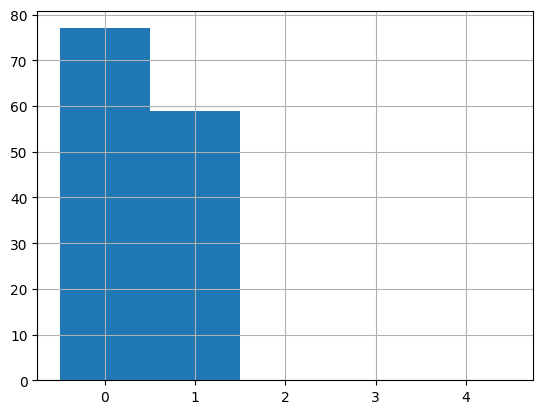

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

## ChemProp Preproc and Cleansing

In [7]:
test_df = test_df.rename(columns={'labels': 'Outcome'})

In [8]:
x_data = test_df

In [9]:
x_data = test_df.drop(columns=['RowID','id', 'casrn', 'smiles (First)','Molecular weight','name','Outcome','Molecule (RDKit Mol) (InChI Code)','reference', 'molecule_form', 'ID',
       'SMILES','Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor','Molecular Weight', 'logP'])

In [10]:
print(x_data)

     nHBDon  nAtomLAC  nAtomLC  PetitjeanNumber  nRotB  LipinskiFailures  \
46        0         2     17.0              0.5     12               0.0   
64        0         2     12.0              0.5      4               0.0   
63        1         1      3.0              0.5      0               0.0   
102       0         8     28.0              0.5     21               0.0   
61        0         2     20.0              0.5     14               0.0   
..      ...       ...      ...              ...    ...               ...   
45        1         1      3.0              0.5      0               0.0   
43        2         2      8.0              0.5      0               0.0   
41        0         2      7.0              0.5      0               0.0   
55        2         4     32.0              0.5      6               0.0   
135       4         3      6.0              0.5      0               0.0   

     TopoPSA   VAdjMat    XLogP      Fsp3      AMW    ALogP     ALogP2  \
46     26.30 

## Data Initiate

In [11]:
x_data  = x_data.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_data

# Display the updated DataFrame
print(test_df)

                id       casrn smiles (First)  Molecular weight  \
46            3479    124-10-7                          242.403   
64   293; 261; 390  17865-32-6                          188.343   
63          314607     75-12-7           NC=O            45.041   
102           1813  56706-10-6                          474.834   
61            2898  93777-46-9                          284.484   
..             ...         ...            ...               ...   
45            3215     64-18-6                           46.025   
43          201472    106-50-3   Nc1ccc(N)cc1           108.144   
41            1491   1609-86-5                           99.133   
55            1738   3068-39-1                          429.540   
135         802256   2231-57-4      NNC(=S)NN           106.154   

                                                  name Outcome  \
46                               methyl tetradecanoate       0   
64                                                   -       0 

In [12]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [13]:
x_test_rdkit_cdk

array([[ 0.,  2., 17., ...,  0.,  0., 17.],
       [ 0.,  2., 12., ...,  0.,  0., 12.],
       [ 1.,  1.,  3., ...,  0.,  0.,  3.],
       ...,
       [ 0.,  2.,  7., ...,  0.,  0.,  7.],
       [ 2.,  4., 32., ...,  0.,  0., 32.],
       [ 4.,  3.,  6., ...,  0.,  0.,  6.]])

## Pharsing and Data Array 

In [14]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [15]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

## Load .pkl Model

In [16]:
#load model - all included
import joblib

# Base paths
fingerprint_path = r"D:\Folder TA - TTX QSAR\Draft fixed\Inhalation\Model\Descriptor"
phys_path        = r"D:\Folder TA - TTX QSAR\Draft fixed\Inhalation\Model\Physiochemical"

# descriptor
rf_morgan   = joblib.load(fr"{fingerprint_path}\Inhalation_rf_morgan.pkl")
rf_maccs    = joblib.load(fr"{fingerprint_path}\Inhalation_rf_maccskey.pkl")
rf_modred   = joblib.load(fr"{fingerprint_path}\Inhalation_rf_modred.pkl")

svm_morgan  = joblib.load(fr"{fingerprint_path}\Inhalation_svm_morgan.pkl")
svm_maccs   = joblib.load(fr"{fingerprint_path}\Inhalation_svm_maccskey.pkl")
svm_modred  = joblib.load(fr"{fingerprint_path}\Inhalation_svm_modred.pkl")

xgb_morgan  = joblib.load(fr"{fingerprint_path}\Inhalation_xgb_morgan.pkl")
xgb_maccs   = joblib.load(fr"{fingerprint_path}\Inhalation_xgb_maccskey.pkl")
xgb_modred  = joblib.load(fr"{fingerprint_path}\Inhalation_xgb_modred.pkl")

nn_morgan   = joblib.load(fr"{fingerprint_path}\Inhalation_nn_morgan.pkl")
nn_maccs    = joblib.load(fr"{fingerprint_path}\Inhalation_nn_maccskey.pkl")
nn_modred   = joblib.load(fr"{fingerprint_path}\Inhalation_nn_modred.pkl")

lgbm_morgan = joblib.load(fr"{fingerprint_path}\Inhalation_lgbm_morgan.pkl")
lgbm_maccs  = joblib.load(fr"{fingerprint_path}\Inhalation_lgbm_maccskey.pkl")
lgbm_modred = joblib.load(fr"{fingerprint_path}\Inhalation_lgbm_modred.pkl")

# physiochemical
rf_p   = joblib.load(fr"{phys_path}\Inhalation_rf_phys.pkl")
svm_p  = joblib.load(fr"{phys_path}\Inhalation_svm_phys.pkl")
xgb_p  = joblib.load(fr"{phys_path}\Inhalation_xgb_phys.pkl")
nn_p   = joblib.load(fr"{phys_path}\Inhalation_nn_phys.pkl")
lgbm_p = joblib.load(fr"{phys_path}\Inhalation_lgbm_phys.pkl")

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


## Physiochemical Consensus and Individual

In [18]:
#Default

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
  
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    
    # Calculate the mean probability across RF and XGB models
    mean_probs = np.mean([rf_probs_rdkitcdk, xgb_probs_rdkitcdk], axis=0)
    
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions, mean_probs, rf_probs_rdkitcdk, xgb_probs_rdkitcdk, svm_probs_rdkitcdk

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs

y_true = test_df['Outcome'].astype(int)  

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix (Consensus):")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy (Consensus):", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score (Consensus):", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')  
print("F1 Score (Consensus):", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity (Consensus):", sensitivity)
print("Specificity (Consensus):", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate) (Consensus):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value) (Consensus):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value) (Consensus):", npv)

# Evaluate RF model alone
rf_predictions = (rf_probs > 0.5).astype(int)
conf_matrix_rf = confusion_matrix(y_true, rf_predictions)
print("Confusion Matrix (RF):")
print(conf_matrix_rf)

accuracy_rf = accuracy_score(y_true, rf_predictions)
print("Accuracy (RF):", accuracy_rf)

auc_score_rf = roc_auc_score(y_true, rf_probs)
print("AUC Score (RF):", auc_score_rf)

f1_rf = f1_score(y_true, rf_predictions, average='binary')
print("F1 Score (RF):", f1_rf)

tn, fp, fn, tp = conf_matrix_rf.ravel()
sensitivity_rf = tp / (tp + fn)
specificity_rf = tn / (tn + fp)
print("Sensitivity (RF):", sensitivity_rf)
print("Specificity (RF):", specificity_rf)

ccr_rf = (sensitivity_rf + specificity_rf) / 2
print("CCR (Correct Classification Rate) (RF):", ccr_rf)

ppv_rf = tp / (tp + fp)
print("PPV (Positive Predictive Value) (RF):", ppv_rf)

npv_rf = tn / (tn + fn)
print("NPV (Negative Predictive Value) (RF):", npv_rf)

# Evaluate XGB model alone
xgb_predictions = (xgb_probs > 0.5).astype(int)
conf_matrix_xgb = confusion_matrix(y_true, xgb_predictions)
print("Confusion Matrix (XGB):")
print(conf_matrix_xgb)

accuracy_xgb = accuracy_score(y_true, xgb_predictions)
print("Accuracy (XGB):", accuracy_xgb)

auc_score_xgb = roc_auc_score(y_true, xgb_probs)
print("AUC Score (XGB):", auc_score_xgb)

f1_xgb = f1_score(y_true, xgb_predictions, average='binary')
print("F1 Score (XGB):", f1_xgb)

tn, fp, fn, tp = conf_matrix_xgb.ravel()
sensitivity_xgb = tp / (tp + fn)
specificity_xgb = tn / (tn + fp)
print("Sensitivity (XGB):", sensitivity_xgb)
print("Specificity (XGB):", specificity_xgb)

ccr_xgb = (sensitivity_xgb + specificity_xgb) / 2
print("CCR (Correct Classification Rate) (XGB):", ccr_xgb)

ppv_xgb = tp / (tp + fp)
print("PPV (Positive Predictive Value) (XGB):", ppv_xgb)

npv_xgb = tn / (tn + fn)
print("NPV (Negative Predictive Value) (XGB):", npv_xgb)

# Evaluate SVM model alone
svm_predictions = (svm_probs > 0.5).astype(int)
conf_matrix_svm = confusion_matrix(y_true, svm_predictions)
print("Confusion Matrix (SVM):")
print(conf_matrix_svm)

accuracy_svm = accuracy_score(y_true, svm_predictions)
print("Accuracy (SVM):", accuracy_svm)

auc_score_svm = roc_auc_score(y_true, svm_probs)
print("AUC Score (SVM):", auc_score_svm)

f1_svm = f1_score(y_true, svm_predictions, average='binary')
print("F1 Score (SVM):", f1_svm)

tn, fp, fn, tp = conf_matrix_svm.ravel()
sensitivity_svm = tp / (tp + fn)
specificity_svm = tn / (tn + fp)
print("Sensitivity (SVM):", sensitivity_svm)
print("Specificity (SVM):", specificity_svm)

ccr_svm = (sensitivity_svm + specificity_svm) / 2
print("CCR (Correct Classification Rate) (SVM):", ccr_svm)

ppv_svm = tp / (tp + fp)
print("PPV (Positive Predictive Value) (SVM):", ppv_svm)

npv_svm = tn / (tn + fn)
print("NPV (Negative Predictive Value) (SVM):", npv_svm)

Confusion Matrix (Consensus):
[[43 34]
 [17 42]]
Accuracy (Consensus): 0.625
AUC Score (Consensus): 0.7046004842615012
F1 Score (Consensus): 0.6222222222222222
Sensitivity (Consensus): 0.711864406779661
Specificity (Consensus): 0.5584415584415584
CCR (Correct Classification Rate) (Consensus): 0.6351529826106097
PPV (Positive Predictive Value) (Consensus): 0.5526315789473685
NPV (Negative Predictive Value) (Consensus): 0.7166666666666667
Confusion Matrix (RF):
[[48 29]
 [18 41]]
Accuracy (RF): 0.6544117647058824
AUC Score (RF): 0.7090028615452343
F1 Score (RF): 0.6356589147286822
Sensitivity (RF): 0.6949152542372882
Specificity (RF): 0.6233766233766234
CCR (Correct Classification Rate) (RF): 0.6591459388069558
PPV (Positive Predictive Value) (RF): 0.5857142857142857
NPV (Negative Predictive Value) (RF): 0.7272727272727273
Confusion Matrix (XGB):
[[39 38]
 [17 42]]
Accuracy (XGB): 0.5955882352941176
AUC Score (XGB): 0.689852520360995
F1 Score (XGB): 0.60431654676259
Sensitivity (XGB): 0.

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Proof of Consensus sampling and Probs

In [19]:
#best choice maybe
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
    X_test = np.array(test_df['rdkit_cdk'].tolist())

    rf_probs = rf_p.predict_proba(X_test)[:, 1]
    xgb_probs = xgb_p.predict_proba(X_test)[:, 1]
    svm_probs = svm_p.predict_proba(X_test)[:, 1]
    nn_probs = nn_p.predict_proba(X_test)[:, 1]
    lgbm_probs = lgbm_p.predict_proba(X_test)[:, 1]

    # Calculate the mean probability across all 5 models
    mean_probs = np.mean([rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs], axis=0)

    # Convert mean probabilities to final class predictions (threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs
test_df['NN_Probabilities'] = nn_probs
test_df['LGBM_Probabilities'] = lgbm_probs

print("\n")
print("="*80)
print("Manual Verification of Consensus Probability")
print("="*80)

for i in range(5):
    rf = rf_probs[i]
    xgb = xgb_probs[i]
    svm = svm_probs[i]
    nn = nn_probs[i]
    lgbm = lgbm_probs[i]

    mean_manual = (rf + xgb + svm + nn + lgbm) / 5

    print(f"\nSample {i+1}")
    print(f"Outcome           : {y_true.iloc[i]}")
    print(f"RF Probability    : {rf:.4f}")
    print(f"XGB Probability   : {xgb:.4f}")
    print(f"SVM Probability   : {svm:.4f}")
    print(f"NN Probability    : {nn:.4f}")
    print(f"LGBM Probability  : {lgbm:.4f}")
    print(f"Mean Probability  : {mean_manual:.4f}")
    print(f"Prediction        : {1 if mean_manual > 0.5 else 0}")

y_true = test_df['Outcome'].astype(int)


def evaluate_model(y_true, probs, label):
    predictions = (probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, predictions)
    print(f"Confusion Matrix ({label}):")
    print(cm)

    accuracy = accuracy_score(y_true, predictions)
    print(f"Accuracy ({label}):", accuracy)

    auc_score = roc_auc_score(y_true, probs)
    print(f"AUC Score ({label}):", auc_score)

    f1 = f1_score(y_true, predictions, average='binary')
    print(f"F1 Score ({label}):", f1)

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity ({label}):", sensitivity)
    print(f"Specificity ({label}):", specificity)

    ccr = (sensitivity + specificity) / 2
    print(f"CCR (Correct Classification Rate) ({label}):", ccr)

    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"PPV (Positive Predictive Value) ({label}):", ppv)

    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    print(f"NPV (Negative Predictive Value) ({label}):", npv)

    print()  # spacer antar model
    return {
        "accuracy": accuracy, "auc": auc_score, "f1": f1,
        "sensitivity": sensitivity, "specificity": specificity,
        "ccr": ccr, "ppv": ppv, "npv": npv
    }


# Evaluate consensus and each individual model
results_consensus = evaluate_model(y_true, mean_probs, "Consensus")
results_rf = evaluate_model(y_true, rf_probs, "RF")
results_xgb = evaluate_model(y_true, xgb_probs, "XGB")
results_svm = evaluate_model(y_true, svm_probs, "SVM")
results_nn = evaluate_model(y_true, nn_probs, "NN")
results_lgbm = evaluate_model(y_true, lgbm_probs, "LGBM")

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(




Manual Verification of Consensus Probability

Sample 1
Outcome           : 0
RF Probability    : 0.2600
XGB Probability   : 0.1963
SVM Probability   : 0.3383
NN Probability    : 0.3610
LGBM Probability  : 0.1798
Mean Probability  : 0.2671
Prediction        : 0

Sample 2
Outcome           : 0
RF Probability    : 0.4800
XGB Probability   : 0.5565
SVM Probability   : 0.5296
NN Probability    : 0.4840
LGBM Probability  : 0.6576
Mean Probability  : 0.5415
Prediction        : 1

Sample 3
Outcome           : 0
RF Probability    : 0.7200
XGB Probability   : 0.6278
SVM Probability   : 0.6508
NN Probability    : 0.8582
LGBM Probability  : 0.7793
Mean Probability  : 0.7272
Prediction        : 1

Sample 4
Outcome           : 0
RF Probability    : 0.2800
XGB Probability   : 0.4518
SVM Probability   : 0.1809
NN Probability    : 0.1356
LGBM Probability  : 0.3646
Mean Probability  : 0.2826
Prediction        : 0

Sample 5
Outcome           : 0
RF Probability    : 0.5400
XGB Probability   : 0.5260
SVM

## Consensus Physiochemical and Mol Desc

In [20]:
#Persis dengan bu yunen
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = rf_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = rf_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[51 26]
 [15 44]]
Accuracy: 0.6985294117647058
AUC Score: 0.7886858903808057
F1 Score: 0.6821705426356589
Sensitivity: 0.7457627118644068
Specificity: 0.6623376623376623
CCR (Correct Classification Rate): 0.7040501871010345
PPV (Positive Predictive Value): 0.6285714285714286
NPV (Negative Predictive Value): 0.7727272727272727


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## RF XGB SVM

In [21]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[51 26]
 [12 47]]
Accuracy: 0.7205882352941176
AUC Score: 0.8106977767994716
F1 Score: 0.7121212121212122
Sensitivity: 0.7966101694915254
Specificity: 0.6623376623376623
CCR (Correct Classification Rate): 0.7294739159145939
PPV (Positive Predictive Value): 0.6438356164383562
NPV (Negative Predictive Value): 0.8095238095238095


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## RF XGB SVM LGBM NN

In [22]:
#best
# rf xgb svm nn(p) lgbm(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    nn_probs_rdkitcdk = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk, nn_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[48 29]
 [14 45]]
Accuracy: 0.6838235294117647
AUC Score: 0.8089368258859785
F1 Score: 0.6766917293233082
Sensitivity: 0.7627118644067796
Specificity: 0.6233766233766234
CCR (Correct Classification Rate): 0.6930442438917015
PPV (Positive Predictive Value): 0.6081081081081081
NPV (Negative Predictive Value): 0.7741935483870968


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Best Result RF XGB SVM LGBM

In [23]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]


    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk, svm_probs_rdkitcdk, rf_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[51 26]
 [11 48]]
Accuracy: 0.7279411764705882
AUC Score: 0.8153202729473916
F1 Score: 0.7218045112781954
Sensitivity: 0.8135593220338984
Specificity: 0.6623376623376623
CCR (Correct Classification Rate): 0.7379484921857804
PPV (Positive Predictive Value): 0.6486486486486487
NPV (Negative Predictive Value): 0.8225806451612904


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Best Model - LGBM RF SVM

In [24]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = lgbm_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]


    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk, svm_probs_rdkitcdk, rf_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[52 25]
 [12 47]]
Accuracy: 0.7279411764705882
AUC Score: 0.8084965881576052
F1 Score: 0.7175572519083969
Sensitivity: 0.7966101694915254
Specificity: 0.6753246753246753
CCR (Correct Classification Rate): 0.7359674224081003
PPV (Positive Predictive Value): 0.6527777777777778
NPV (Negative Predictive Value): 0.8125


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Read Accross

In [25]:
#Read-Across (Tanimoto Similarity, Morgan Fingerprint, k=5, weighted) - Eye

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Load train_df =====
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Inhalation toxicity\dataset\test_set_acute_inhalation_features.sdf')

def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df = train_df.rename(columns={"labels": "Outcome"})


train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.shape)


# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Siapkan data =====
X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
y_train = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values

X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())
y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# ===== Jalankan read-across =====
readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train, k=5)
readacross_predictions = (readacross_probs > 0.5).astype(int)

test_df['ReadAcross_Probabilities'] = readacross_probs
test_df['ReadAcross_Predictions'] = readacross_predictions

# ===== Evaluasi =====
conf_matrix_ra = confusion_matrix(y_true, readacross_predictions)
print("Confusion Matrix (Read-Across):")
print(conf_matrix_ra)

accuracy_ra = accuracy_score(y_true, readacross_predictions)
print("Accuracy (Read-Across):", accuracy_ra)

auc_score_ra = roc_auc_score(y_true, readacross_probs)
print("AUC Score (Read-Across):", auc_score_ra)

f1_ra = f1_score(y_true, readacross_predictions, average='binary')
print("F1 Score (Read-Across):", f1_ra)

tn, fp, fn, tp = conf_matrix_ra.ravel()
sensitivity_ra = tp / (tp + fn)
specificity_ra = tn / (tn + fp)
print("Sensitivity (Read-Across):", sensitivity_ra)
print("Specificity (Read-Across):", specificity_ra)

ccr_ra = (sensitivity_ra + specificity_ra) / 2
print("CCR (Correct Classification Rate) (Read-Across):", ccr_ra)

ppv_ra = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Read-Across):", ppv_ra)

npv_ra = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Read-Across):", npv_ra)

Train DataFrame:
     id       casrn smiles (First)    Molecular weight  \
0  2564     64-19-7                  60.05195999145508   
1  1454    110-76-9                  90.14418029785156   
2  3979     75-76-3                  88.22357940673828   
3  1715    382-10-5                 164.04910278320312   
4   610  77501-63-4                  461.7731018066406   

                                            name Outcome  \
0                                    acetic acid       1   
1                             2-ethoxyethanamine       0   
2                              tetramethylsilane       0   
3  3,3,3-trifluoro-2-(trifluoromethyl)prop-1-ene       1   
4                                              -       0   

                   Molecule (RDKit Mol) (InChI Code) reference molecule_form  \
0              InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)      ECHA             V   
1           InChI=1S/C4H11NO/c1-2-6-4-3-5/h2-5H2,1H3      ECHA             V   
2                 InChI=1S/C4H12S

## RA Maccskeys

In [27]:
#Read-Across (Tanimoto Similarity, Morgan Fingerprint, k=5, weighted) - Inhalation

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Load train_df =====
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Inhalation toxicity\dataset\test_set_acute_inhalation_features.sdf')

def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.shape)


# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5, power=1):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        # ----- Bobot dipangkatkan (power=1: linear, power=2: kuadrat, dst) -----
        top_k_weights = top_k_sims ** power

        total_weight = np.sum(top_k_weights)
        if total_weight > 0:
            weighted_pred = np.sum(top_k_weights * top_k_labels) / total_weight
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Siapkan data =====
X_train_morgan = np.array(train_df['MACCS_Descriptors'].tolist())
y_train = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values

X_test_morgan = np.array(test_df['MACCS_Descriptors'].tolist())
y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# ===== Jalankan read-across =====
readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train, k=5)
readacross_predictions = (readacross_probs > 0.5).astype(int)

test_df['ReadAcross_Probabilities'] = readacross_probs
test_df['ReadAcross_Predictions'] = readacross_predictions

# ===== Evaluasi =====
conf_matrix_ra = confusion_matrix(y_true, readacross_predictions)
print("Confusion Matrix MACCS (Read-Across):")
print(conf_matrix_ra)

accuracy_ra = accuracy_score(y_true, readacross_predictions)
print("Accuracy (Read-Across):", accuracy_ra)

auc_score_ra = roc_auc_score(y_true, readacross_probs)
print("AUC Score (Read-Across):", auc_score_ra)

f1_ra = f1_score(y_true, readacross_predictions, average='binary')
print("F1 Score (Read-Across):", f1_ra)

tn, fp, fn, tp = conf_matrix_ra.ravel()
sensitivity_ra = tp / (tp + fn)
specificity_ra = tn / (tn + fp)
print("Sensitivity (Read-Across):", sensitivity_ra)
print("Specificity (Read-Across):", specificity_ra)

ccr_ra = (sensitivity_ra + specificity_ra) / 2
print("CCR (Correct Classification Rate) (Read-Across):", ccr_ra)

ppv_ra = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Read-Across):", ppv_ra)

npv_ra = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Read-Across):", npv_ra)

Train DataFrame:
     id       casrn smiles (First)    Molecular weight  \
0  2564     64-19-7                  60.05195999145508   
1  1454    110-76-9                  90.14418029785156   
2  3979     75-76-3                  88.22357940673828   
3  1715    382-10-5                 164.04910278320312   
4   610  77501-63-4                  461.7731018066406   

                                            name Outcome  \
0                                    acetic acid       1   
1                             2-ethoxyethanamine       0   
2                              tetramethylsilane       0   
3  3,3,3-trifluoro-2-(trifluoromethyl)prop-1-ene       1   
4                                              -       0   

                   Molecule (RDKit Mol) (InChI Code) reference molecule_form  \
0              InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)      ECHA             V   
1           InChI=1S/C4H11NO/c1-2-6-4-3-5/h2-5H2,1H3      ECHA             V   
2                 InChI=1S/C4H12S

## QRASAR Morgan

In [28]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]


    # ----- Read-Across -----
    X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk ,lgbm_probs_rdkitcdk, svm_probs_rdkitcdk, rf_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[64 13]
 [ 8 51]]
Accuracy: 0.8455882352941176
AUC Score: 0.9075500770416025
F1 Score: 0.8292682926829268
Sensitivity: 0.864406779661017
Specificity: 0.8311688311688312
CCR (Correct Classification Rate): 0.8477878054149242
PPV (Positive Predictive Value): 0.796875
NPV (Negative Predictive Value): 0.8888888888888888


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_maccs = np.array(train_df['MACCS_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_maccs = np.array(test_df['MACCS_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_maccs, X_train_maccs, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk ,lgbm_probs_rdkitcdk, svm_probs_rdkitcdk, rf_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs

# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[60 17]
 [ 9 50]]
Accuracy: 0.8088235294117647
AUC Score: 0.888399735857363
F1 Score: 0.7936507936507936
Sensitivity: 0.847457627118644
Specificity: 0.7792207792207793
CCR (Correct Classification Rate): 0.8133392031697116
PPV (Positive Predictive Value): 0.746268656716418
NPV (Negative Predictive Value): 0.8695652173913043


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## XAI


Menghitung SHAP values XGB...
Type: <class 'numpy.ndarray'>
Shape: (136, 56)
Shape final: (136, 56)


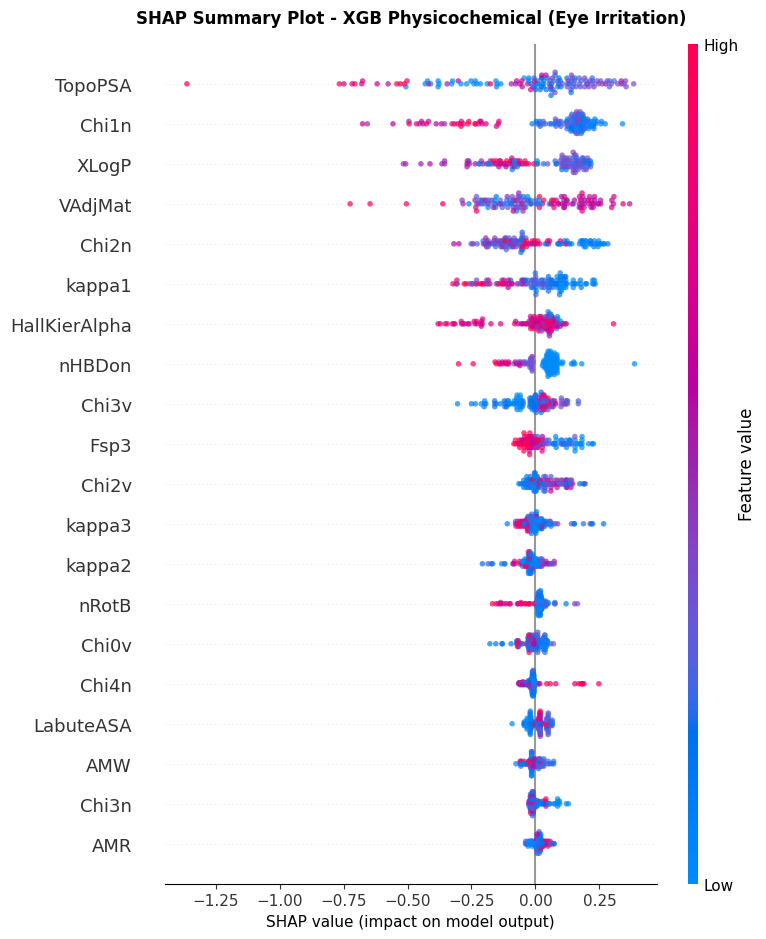

Plot tersimpan: shap_Inhalation.png


In [24]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP',
'Fsp3', 'AMW', 'ALogP', 'ALogP2', 'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA', 'nHBAcc', 
'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds', 'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings', 
'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 
'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v',
'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 'FractionCSP3', 'bpol', 'nB', 
'ECCEN', 'nAtomP', 'fragC'
]

# ===== FIX: konversi eksplisit ke float64 =====
X_phys = pd.DataFrame(
    np.array(x_test_rdkit_cdk, dtype=np.float64),
    columns=feature_names
)

# Verifikasi dtype
print("Dtype setelah konversi:")
print(X_phys.dtypes.value_counts())
print(f"Shape: {X_phys.shape}")

# ===== XGBoost SHAP =====
print("\nMenghitung SHAP values XGB...")
explainer_xgb = shap.TreeExplainer(xgb_p)
shap_values_xgb = explainer_xgb.shap_values(X_phys)

print(f"Type: {type(shap_values_xgb)}")
print(f"Shape: {np.array(shap_values_xgb).shape}")

shap_vals = np.array(shap_values_xgb)
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    plot_type="dot",
    max_display=20,
    show=False,
    alpha=0.7
)
plt.title("SHAP Summary Plot - XGB Physicochemical (Eye Irritation)",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Inhalation.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Inhalation.png")

Dtype setelah konversi:
float64    56
dtype: int64
Shape: (136, 56)

Menghitung SHAP values XGB...
Type: <class 'numpy.ndarray'>
Shape: (136, 56)
Shape final: (136, 56)


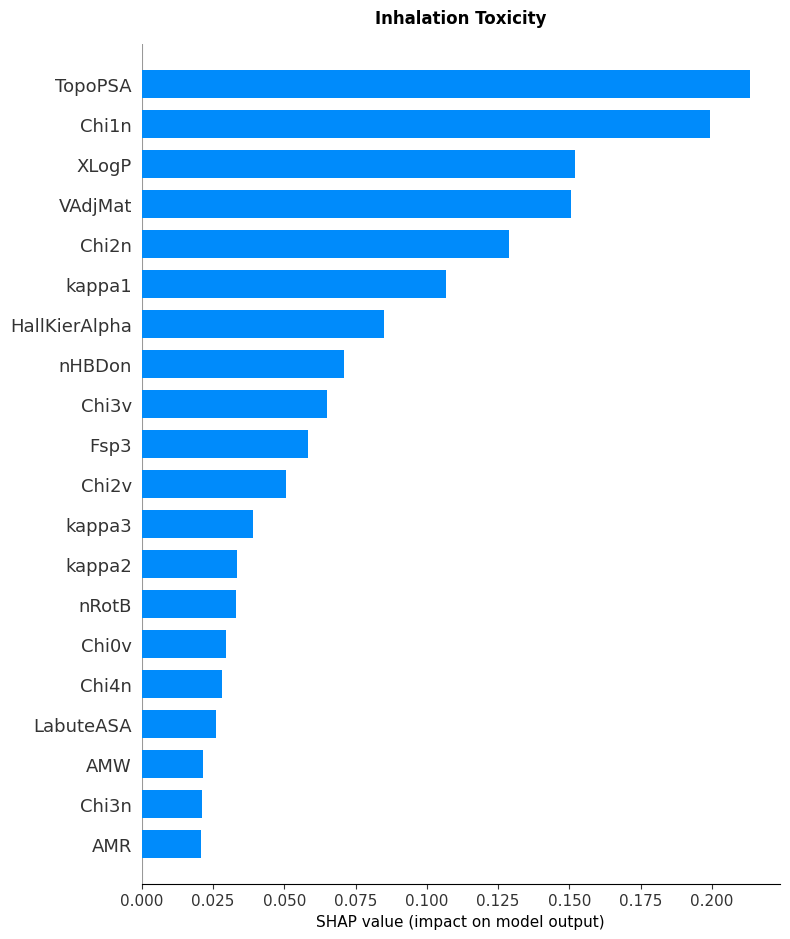

Plot tersimpan: shap_Inhalation.png


In [25]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP',
'Fsp3', 'AMW', 'ALogP', 'ALogP2', 'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA', 'nHBAcc', 
'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds', 'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings', 
'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 
'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v',
'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 'FractionCSP3', 'bpol', 'nB', 
'ECCEN', 'nAtomP', 'fragC'
]

# ===== FIX: konversi eksplisit ke float64 =====
X_phys = pd.DataFrame(
    np.array(x_test_rdkit_cdk, dtype=np.float64),
    columns=feature_names
)

# Verifikasi dtype
print("Dtype setelah konversi:")
print(X_phys.dtypes.value_counts())
print(f"Shape: {X_phys.shape}")

# ===== XGBoost SHAP =====
print("\nMenghitung SHAP values XGB...")
explainer_xgb = shap.TreeExplainer(xgb_p)
shap_values_xgb = explainer_xgb.shap_values(X_phys)

print(f"Type: {type(shap_values_xgb)}")
print(f"Shape: {np.array(shap_values_xgb).shape}")

shap_vals = np.array(shap_values_xgb)
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    plot_type="bar",
    max_display=20,
    show=False,
    alpha=0.7
)
plt.title("Inhalation Toxicity",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Inhalation_bar.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Inhalation.png")

In [ ]:
'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP',
'Fsp3', 'AMW', 'ALogP', 'ALogP2', 'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA', 'nHBAcc', 
'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds', 'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings', 
'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 
'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v',
'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 'FractionCSP3', 'bpol', 'nB', 
'ECCEN', 'nAtomP'